# Teoría: de ΔG° a K(T) y al sistema de ecuaciones en ξ

Cuaderno de **estudio** (no de cálculo de tareas). Cada bloque de teoría va seguido
de una celda que usa `core.thermo` / `core.equilibrium` con los datos de
`data/sva_tables.json` (Tablas C.1 y C.4 de Smith–Van Ness–Abbott, SVA) para un
ejemplo concreto. Los ejercicios validados viven en `ejercicios/*.py`; este cuaderno
solo explica lo que ese código hace.

Convenciones: T en K, ΔH° y ΔG° en J/mol, R = 8.314 J/(mol·K), T₀ = 298.15 K,
P° = 1 bar.

In [1]:
# Shim de sys.path: mismo que en los scripts (parents[1] + búsqueda de core/ hacia arriba)
import sys, pathlib
try:
    _RAIZ = pathlib.Path(__file__).resolve().parents[1]          # raíz del proyecto
except NameError:                                                # celda/notebook sin __file__
    _RAIZ = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
                  if (p / "core" / "exercise.py").exists()), None)
    if _RAIZ is None:
        raise RuntimeError("no encuentro core/ desde el cwd: corre el kernel "
                           "con la carpeta del notebook como directorio de trabajo")
sys.path.insert(0, str(_RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad

from core.thermo import (R_J, T_REF, cargar_datos, cp_R, icph, icps,
                         reaction_thermo, K_vant_hoff)
from core.equilibrium import solve_extents
from core.reactions import parse_reaction, build_system

datos = cargar_datos(["CO", "H2O", "CO2", "H2", "N2", "NH3", "C3H8", "C2H4", "CH4", "C3H6"])
pd.DataFrame(datos).T[["nombre", "Hf298", "Gf298", "A", "B", "C", "D", "Tmax"]]

,nombre,Hf298,Gf298,A,B,C,D,Tmax
CO,monóxido de carbono,-110525.0,-137169.0,3.376,0.000557,0.0,-3100.0,2500.0
H2O,agua,-241818.0,-228572.0,3.47,0.00145,0.0,12100.0,2000.0
CO2,dióxido de carbono,-393509.0,-394359.0,5.457,0.001045,0.0,-115700.0,2000.0
H2,hidrógeno,0.0,0.0,3.249,0.000422,0.0,8300.0,3000.0
N2,nitrógeno,0.0,0.0,3.28,0.000593,0.0,4000.0,2000.0
NH3,amoniaco,-46110.0,-16450.0,3.578,0.00302,0.0,-18600.0,1800.0
C3H8,propano,-104680.0,-24290.0,1.213,0.028785,-0.000009,0.0,1500.0
C2H4,etileno,52510.0,68460.0,1.424,0.014394,-0.000004,0.0,1500.0
CH4,metano,-74520.0,-50460.0,1.702,0.009081,-0.000002,0.0,1500.0
C3H6,propileno,19710.0,62205.0,1.637,0.022706,-0.000007,0.0,1500.0


## 1. Ecuación 13.18 de SVA: de ΔG°(T) a K(T)

La constante de equilibrio se define a partir de la energía de Gibbs estándar de reacción:

$$\ln K = -\frac{\Delta G^\circ(T)}{RT}, \qquad \Delta G^\circ = \sum_i \nu_i\, G^\circ_{f,i}$$

A 298.15 K basta con las energías de formación de la Tabla C.4. A otra T hay que
"mover" ΔH° y ΔS° con ΔCp°(T). Combinando $\Delta H^\circ(T) = \Delta H^\circ_{298} + R\,\mathrm{ICPH}$ y
$\Delta S^\circ(T) = \Delta S^\circ_{298} + R\,\mathrm{ICPS}$ con $\Delta G^\circ = \Delta H^\circ - T\Delta S^\circ$ se llega a la
**ec. 13.18**:

$$\frac{\Delta G^\circ(T)}{RT} = \frac{\Delta G^\circ_{298} - \Delta H^\circ_{298}}{R\,T_0}
+ \frac{\Delta H^\circ_{298}}{R\,T} + \frac{1}{T}\,\mathrm{ICPH}(T_0, T) - \mathrm{ICPS}(T_0, T)$$

con $\mathrm{ICPH} = \int_{T_0}^{T} \frac{\Delta C_p^\circ}{R}\,dT$ y
$\mathrm{ICPS} = \int_{T_0}^{T} \frac{\Delta C_p^\circ}{R}\,\frac{dT}{T}$.
Eso es exactamente lo que implementa `core.thermo.reaction_thermo(nu, datos, T)`.

**Ejemplo de verificación (SVA, ej. 13.4):** water-gas shift
$\mathrm{CO + H_2O \rightleftharpoons CO_2 + H_2}$ a 1100 K debe dar $K \approx 1.006$.

In [2]:
wgs = parse_reaction("CO + H2O = CO2 + H2")      # {especie: nu}, reactivos < 0
t = reaction_thermo(wgs, datos, 1100.0)
print(f"WGS a 1100 K:  dH° = {t['dH']/1000:.3f} kJ/mol   dG° = {t['dG']/1000:.4f} kJ/mol   K = {t['K']:.4f}")
assert abs(t["K"] - 1.006) < 1e-3, t["K"]
print("OK: K_WGS(1100 K) ≈ 1.006 (SVA ej. 13.4)")

pd.DataFrame({T: reaction_thermo(wgs, datos, T) for T in (298.15, 500, 800, 1100, 1500)}).T \
  .rename(columns={"dH298": "ΔH°298", "dG298": "ΔG°298", "dCp_R": "ΔCp°/R(T)", "dH": "ΔH°(T)", "dG": "ΔG°(T)"})

WGS a 1100 K:  dH° = -33.649 kJ/mol   dG° = -0.0529 kJ/mol   K = 1.0058
OK: K_WGS(1100 K) ≈ 1.006 (SVA ej. 13.4)


,ΔH°298,ΔG°298,ΔCp°/R(T),ΔH°(T),ΔG°(T),K
298.15,-41166.0,-28618.0,0.389566,-41166.000000,-28618.000000,103260.841803
500.00,-41166.0,-28618.0,1.124400,-39716.581212,-20464.008273,137.384401
800.00,-41166.0,-28618.0,1.246125,-36678.645612,-9668.002588,4.278372
1100.00,-41166.0,-28618.0,1.169802,-33648.872848,-52.949620,1.005807
1500.00,-41166.0,-28618.0,0.998267,-30032.434012,11556.813839,0.395860


## 2. Integración de Cp(T) con las constantes A, B, C, D

La Tabla C.1 de SVA ajusta cada especie como

$$\frac{C_p^\circ}{R} = A + B\,T + C\,T^2 + D\,T^{-2}$$

y para la reacción $\Delta A = \sum_i \nu_i A_i$ (igual para B, C, D). Las dos integrales
tienen forma cerrada:

$$\mathrm{ICPH} = \Delta A\,(T - T_0) + \frac{\Delta B}{2}(T^2 - T_0^2) + \frac{\Delta C}{3}(T^3 - T_0^3) - \Delta D\left(\frac{1}{T} - \frac{1}{T_0}\right)$$

$$\mathrm{ICPS} = \Delta A \ln\frac{T}{T_0} + \Delta B\,(T - T_0) + \frac{\Delta C}{2}(T^2 - T_0^2) - \frac{\Delta D}{2}\left(\frac{1}{T^2} - \frac{1}{T_0^2}\right)$$

Son `core.thermo.icph` e `icps`. Abajo se comprueban contra una integración numérica
(`scipy.integrate.quad`) para el WGS a 1100 K. Nota que ΔCp° del WGS es pequeño y
cambia de signo: por eso ΔH°(T) se mueve poco (−41.2 → −33.6 kJ/mol) aunque T suba 800 K.

In [3]:
T = 1100.0
dA, dB, dC, dD = (sum(nu * datos[sp][k] for sp, nu in wgs.items()) for k in "ABCD")
print(f"ΔA = {dA:.4f}   ΔB = {dB:.3e}   ΔC = {dC:.3e}   ΔD = {dD:.1f}")

icph_cerrada = icph(T_REF, T, dA, dB, dC, dD)
icps_cerrada = icps(T_REF, T, dA, dB, dC, dD)
icph_num, _ = quad(lambda t: cp_R(t, dA, dB, dC, dD), T_REF, T)
icps_num, _ = quad(lambda t: cp_R(t, dA, dB, dC, dD) / t, T_REF, T)
print(f"ICPH: cerrada {icph_cerrada:.6f} K   numérica {icph_num:.6f} K")
print(f"ICPS: cerrada {icps_cerrada:.6f}     numérica {icps_num:.6f}")
assert abs(icph_cerrada - icph_num) < 1e-6 and abs(icps_cerrada - icps_num) < 1e-9

# Reconstrucción explícita de la ec. 13.18 (mismo número que reaction_thermo)
dH0 = sum(nu * datos[sp]["Hf298"] for sp, nu in wgs.items())
dG0 = sum(nu * datos[sp]["Gf298"] for sp, nu in wgs.items())
dG_RT = (dG0 - dH0) / (R_J * T_REF) + dH0 / (R_J * T) + icph_cerrada / T - icps_cerrada
print(f"ΔG°/RT = {dG_RT:.6f}   →   K = exp(−ΔG°/RT) = {np.exp(-dG_RT):.4f}")

pd.DataFrame({sp: {"ν": nu, **{k: datos[sp][k] for k in "ABCD"}, "Cp/R(1100 K)": cp_R(T, *(datos[sp][k] for k in "ABCD"))}
              for sp, nu in wgs.items()}).T

ΔA = 1.8600   ΔB = -5.400e-04   ΔC = 0.000e+00   ΔD = -116400.0
ICPH: cerrada 904.152893 K   numérica 904.152893 K
ICPS: cerrada 1.388555     numérica 1.388555
ΔG°/RT = -0.005790   →   K = exp(−ΔG°/RT) = 1.0058


,ν,A,B,C,D,Cp/R(1100 K)
CO,-1.0,3.376,0.000557,0.0,-3100.0,3.986138
H2O,-1.0,3.470,0.001450,0.0,12100.0,5.075000
CO2,1.0,5.457,0.001045,0.0,-115700.0,6.510880
H2,1.0,3.249,0.000422,0.0,8300.0,3.720060


## 3. Verificación con la síntesis de amoniaco (SVA, ej. 13.5)

$$\tfrac{1}{2}\,\mathrm{N_2} + \tfrac{3}{2}\,\mathrm{H_2} \rightleftharpoons \mathrm{NH_3}$$

A 298.15 K las integrales valen cero y $K = \exp(-\Delta G^\circ_{f,\mathrm{NH_3}}/RT_0)$ con
ΔG°f = −16 450 J/mol: $K \approx 762$. A 500 K, con ΔCp°(T) incluido, $K \approx 0.316$.
(La reacción es exotérmica, así que K cae mucho al subir T.)

In [4]:
nh3 = parse_reaction("1/2 N2 + 3/2 H2 = NH3")
K298 = reaction_thermo(nh3, datos, 298.15)["K"]
K500 = reaction_thermo(nh3, datos, 500.0)["K"]
print(f"K_NH3(298.15 K) = {K298:.1f}      K_NH3(500 K) = {K500:.4f}")
assert abs(K298 - 762) < 1.0, K298
assert abs(K500 - 0.316) < 1e-3, K500
print("OK: K_NH3(298 K) ≈ 762 y K_NH3(500 K) ≈ 0.316 (SVA ej. 13.5)")

K_NH3(298.15 K) = 762.2      K_NH3(500 K) = 0.3163
OK: K_NH3(298 K) ≈ 762 y K_NH3(500 K) ≈ 0.316 (SVA ej. 13.5)


## 4. Van't Hoff: por qué ln K es ~lineal en 1/T

Derivando $\ln K = -\Delta G^\circ/RT$ respecto a T (con Gibbs–Helmholtz):

$$\frac{d\ln K}{dT} = \frac{\Delta H^\circ}{RT^2}
\quad\Longleftrightarrow\quad
\frac{d\ln K}{d(1/T)} = -\frac{\Delta H^\circ}{R}$$

Si ΔH° se toma constante (ΔCp° = 0) la integral es la forma que usa `core.thermo.K_vant_hoff`:

$$\ln\frac{K}{K_0} = -\frac{\Delta H^\circ}{R}\left(\frac{1}{T} - \frac{1}{T_0}\right)$$

Es una recta en el plano (1/T, ln K) con pendiente −ΔH°/R: exotérmica → pendiente
positiva (K baja con T), endotérmica → negativa. La ec. 13.18 incluye la curvatura por
ΔCp°(T). En la gráfica: línea continua = ec. 13.18; punteada = Van't Hoff con ΔH°298
constante. Para el NH3 a 500 K la aproximación da 0.418 en vez de 0.316 (32 % arriba);
para el WGS, con ΔCp° pequeño, casi no se nota.

WGS: CO + H2O = CO2 + H2: pendiente −ΔH°298/R =   4951.4 K   (exotérmica)
NH3: 1/2 N2 + 3/2 H2 = NH3: pendiente −ΔH°298/R =   5546.1 K   (exotérmica)


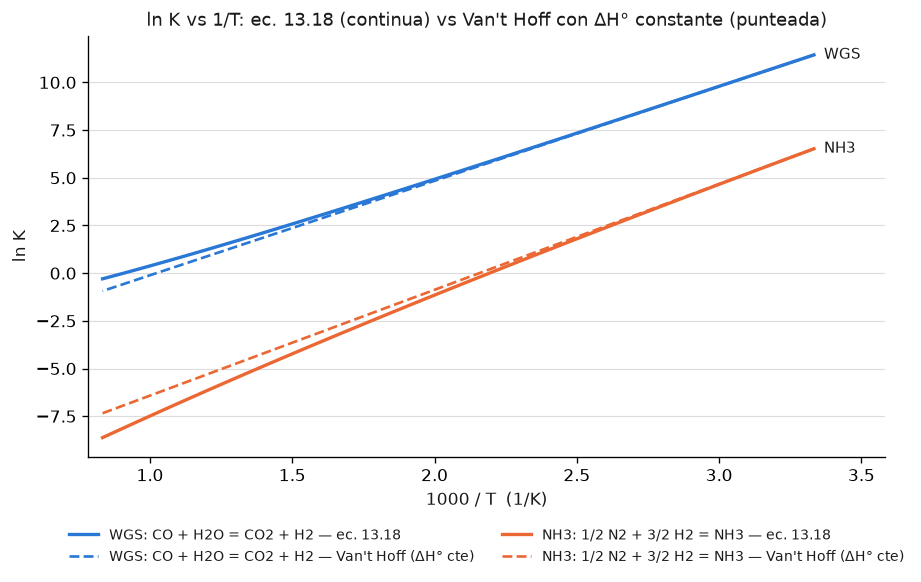


NH3 a 500 K:  ec. 13.18 = 0.3163   Van't Hoff = 0.4176


In [5]:
_PALETA = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",   # misma paleta que core/exercise.py
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
_TINTA = "#1a1a19"

reacciones_plot = {"WGS: CO + H2O = CO2 + H2": wgs, "NH3: 1/2 N2 + 3/2 H2 = NH3": nh3}
Ts = np.linspace(300, 1200, 60)

fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
for k, (nombre, nu) in enumerate(reacciones_plot.items()):
    t0 = reaction_thermo(nu, datos, T_REF)
    lnK_exacta = [np.log(reaction_thermo(nu, datos, T)["K"]) for T in Ts]
    lnK_vh = [np.log(K_vant_hoff(T, t0["K"], t0["dH298"])) for T in Ts]
    ax.plot(1000 / Ts, lnK_exacta, color=_PALETA[k], lw=2, label=f"{nombre} — ec. 13.18")
    ax.plot(1000 / Ts, lnK_vh, color=_PALETA[k], lw=1.6, ls="--", label=f"{nombre} — Van't Hoff (ΔH° cte)")
    ax.annotate(nombre.split(":")[0], (1000 / Ts[0], lnK_exacta[0]), xytext=(6, 0),
                textcoords="offset points", ha="left", va="center", fontsize=9, color=_TINTA)
    print(f"{nombre}: pendiente −ΔH°298/R = {-t0['dH298']/R_J:8.1f} K   ({'exotérmica' if t0['dH298'] < 0 else 'endotérmica'})")

ax.set_xlim(1000 / Ts[-1] - 0.05, 1000 / Ts[0] + 0.25)
ax.set_xlabel("1000 / T  (1/K)", color=_TINTA)
ax.set_ylabel("ln K", color=_TINTA)
ax.set_title("ln K vs 1/T: ec. 13.18 (continua) vs Van't Hoff con ΔH° constante (punteada)",
             color=_TINTA, fontsize=10.5)
ax.grid(axis="y", color="#dddddd", lw=0.7)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=False, fontsize=8.5, labelcolor=_TINTA)
fig.tight_layout()
plt.show()

print(f"\nNH3 a 500 K:  ec. 13.18 = {K500:.4f}   Van't Hoff = {K_vant_hoff(500, reaction_thermo(nh3, datos, T_REF)['K'], reaction_thermo(nh3, datos, T_REF)['dH298']):.4f}")

## 5. Reacciones simultáneas: el sistema de ecuaciones en ξ

Con $r$ reacciones y matriz estequiométrica $\nu_{ij}$ (fila j = reacción, columna i = especie),
cada avance $\xi_j$ fija los moles de todas las especies:

$$n_i = n_{i0} + \sum_j \nu_{ij}\,\xi_j, \qquad n_T = n_{T0} + \sum_j \delta_j\,\xi_j, \qquad \delta_j = \sum_i \nu_{ij}$$

y las fracciones mol $y_i = n_i / n_T$. En fase gas ideal cada reacción impone

$$K_j = \prod_i y_i^{\nu_{ij}} \left(\frac{P}{P^\circ}\right)^{\delta_j}$$

Son $r$ ecuaciones no lineales en las $r$ incógnitas $\xi_j$. `core.equilibrium.solve_extents`
las resuelve en **forma logarítmica** (así K de 10⁻³ a 10¹⁰ quedan bien condicionadas):

$$r_j(\boldsymbol{\xi}) = \sum_i \nu_{ij} \ln y_i + \delta_j \ln\frac{P}{P^\circ} - \ln K_j = 0$$

con jacobiano analítico
$\partial r_j/\partial \xi_k = \sum_i \nu_{ij}\nu_{ik}/n_i - \delta_j\delta_k/n_T$,
mínimos cuadrados (`scipy.optimize.least_squares`, método TRF), penalización si algún
$n_i < 0$ y arranques múltiples desde avances factibles aleatorios. `selfcheck` después
re-resuelve desde otros arranques (punto 8) y recalcula $K$ desde la solución (punto 6).

**Ejemplo:** pirólisis de propano, $\mathrm{C_3H_8 = C_2H_4 + CH_4}$ y $\mathrm{C_3H_8 = C_3H_6 + H_2}$,
10 mol de C₃H₈, 1 bar, 900 K, con las K de la ec. 13.18. Abajo se arma nu con
`core.reactions.build_system`, se resuelve, y se evalúan los residuales $r_j$ a mano
a partir de la solución: deben ser ~0.

In [6]:
reacciones = ["C3H8 = C2H4 + CH4", "C3H8 = C3H6 + H2"]
alimentacion = {"C3H8": 10.0}
T, P, P0 = 900.0, 1.0, 1.0

especies, nu, atomos, inertes = build_system(reacciones, alimentacion)
nu_arr = np.array(nu, dtype=float)
delta = nu_arr.sum(axis=1)
K = [reaction_thermo(parse_reaction(rx), datos, T)["K"] for rx in reacciones]
print("Especies:", especies, "   δ_j =", delta, "   K_j =", np.round(K, 5))
print("nu =\n", pd.DataFrame(nu, index=["R1", "R2"], columns=especies))

res = solve_extents(especies, alimentacion, nu, K, P=P, P0=P0, atoms=atomos)
print(f"\n{res.message}   ξ = {np.round(res.xi, 5)}   n_T = {res.n_total:.5f}")

# residuales logarítmicos evaluados en la solución (lo que el solver llevó a cero)
r = nu_arr @ np.log(res.y) + delta * np.log(P / P0) - np.log(K)
print("r_j(ξ*) =", r)
assert np.all(np.abs(r) < 1e-6)

pd.DataFrame({"n_i (mol)": res.moles, "y_i": res.mole_fractions}).round(6)

Especies: ['C3H8', 'C2H4', 'CH4', 'C3H6', 'H2']    δ_j = [1. 1.]    K_j = [187.7306    0.51655]
nu =
     C3H8  C2H4  CH4  C3H6   H2
R1  -1.0   1.0  1.0   0.0  0.0
R2  -1.0   0.0  0.0   1.0  1.0

converged   ξ = [9.47883 0.49722]   n_T = 19.97604
r_j(ξ*) = [ 3.55271368e-15 -1.58761893e-14]


,n_i (mol),y_i
C3H8,0.023959,0.001199
C2H4,9.478826,0.474510
CH4,9.478826,0.474510
C3H6,0.497215,0.024891
H2,0.497215,0.024891


## Dónde sigue esto en el código

- `core/thermo.py`: `reaction_thermo` (ec. 13.18), `icph`/`icps`, `K_vant_hoff`, `cargar_datos`.
- `core/reactions.py`: texto de la reacción → `nu`, átomos, inertes (`build_system`).
- `core/equilibrium.py`: `solve_extents` (Método A, residuales logarítmicos) y Método B.
- `core/selfcheck.py`: los 12 puntos de autovalidación (`validate`, `validate_sweep`).
- `core/exercise.py`: `run_exercise` encadena todo lo anterior para la plantilla.

Los ejercicios canónicos y validados son los `.py` de `ejercicios/`; este cuaderno y
`ej2_reporte.ipynb` son material de estudio y de reporte.